<a href="https://colab.research.google.com/github/monetneva/AFRL-PROJECT/blob/Monet-branch/svm%5Bcolab%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
import librosa  # type: ignore
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=2)
    return np.mean(mfcc, axis=1)  # use 2 features for 2D plot

In [ ]:
train_dir = '/content/drive/MyDrive/25SummerInternsRepo/TraceSysDemo/Acoustic_train_test/EII_Raw_Ac_Fusion_Data_Train'
train_files = [f for f in os.listdir(train_dir) if f.endswith('.wav')]

X = []
y = []

def get_label(fname):
    if 'A2' in fname or 'drone' in fname:
        return 'drone'
    elif 'V1' in fname or 'car' in fname:
        return 'car'
    else:
        return 'unknown'

for file in train_files:
    path = os.path.join(train_dir, file)
    features = extract_features(path)
    label = get_label(file)
    if label != 'unknown':
        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)

# encoding 'drone' and 'car' labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# scales features so that they have zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1599
  warnings.warn(


In [ ]:
model = SVC(kernel='rbf')
model.fit(X_scaled, y_encoded)

SVC()

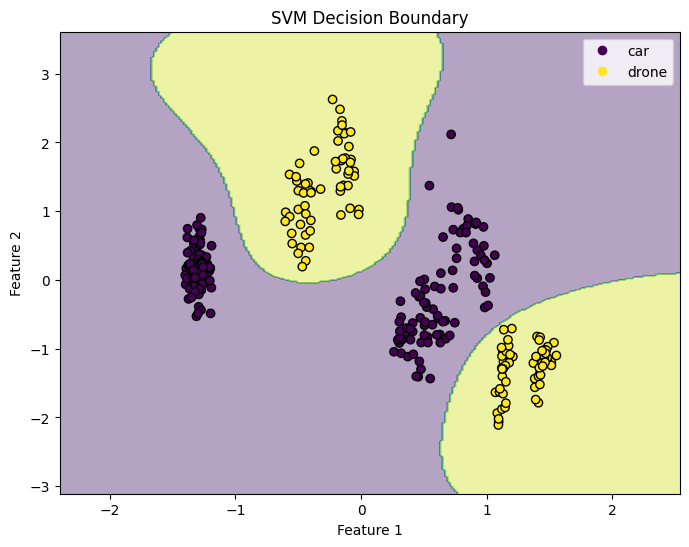

In [ ]:
def plot_svm_decision_boundary(X, y, model):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("SVM Decision Boundary")
    plt.legend(handles=scatter.legend_elements()[0], labels=label_encoder.classes_.tolist())
    plt.show()

plot_svm_decision_boundary(X_scaled, y_encoded, model)

In [13]:
test_dir = '/content/drive/MyDrive/25SummerInternsRepo/TraceSysDemo/Acoustic_train_test/EII_Raw_Ac_Fusion_Data_Test'
test_files = [f for f in os.listdir(test_dir) if f.endswith('.wav')]

X_test = []
y_test = []

for file in test_files:
    path = os.path.join(test_dir, file)
    features = extract_features(path)
    label = get_label(file)
    if label != 'unknown':
        X_test.append(features)
        y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

y_test_encoded = label_encoder.transform(y_test)
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print("\n=== Classification Report ===")
print(classification_report(y_test_encoded, y_pred, target_names=label_encoder.classes_))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test_encoded, y_pred))


/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1599
  warnings.warn(



=== Classification Report ===
              precision    recall  f1-score   support

         car       0.98      0.83      0.90       180
       drone       0.79      0.97      0.87       120

    accuracy                           0.89       300
   macro avg       0.89      0.90      0.89       300
weighted avg       0.90      0.89      0.89       300


=== Confusion Matrix ===
[[149  31]
 [  3 117]]


# ---- trying to get 2-sec sample analysis

In [27]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=2)
    return np.mean(mfcc, axis=1)

def extract_features_s(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=2)
    return np.mean(mfcc, axis=1)

In [28]:
def analyze_long_audio(file_path, window_sec=2.0, sr=48000):
    y, audio_sr = librosa.load(file_path, sr=sr)
    window_samples = int(window_sec * audio_sr)
    print("\nAnalyzing audio in {} second windows".format(window_sec))

    for i in range(0, len(y), window_samples):
        segment = y[i:i+window_samples]
        if len(segment) < window_samples:
            break

        features = extract_features_s(segment, sr=audio_sr)

        features = features.reshape(1, -1)

        features_scaled = scaler.transform(features)

        predicted_encoded = model.predict(features_scaled)

        predicted_label = label_encoder.inverse_transform(predicted_encoded)[0]

        start_sec = i / audio_sr
        end_sec = (i + len(segment)) / audio_sr # end time

        print("From {:.2f}s to {:.2f}s: {}".format(start_sec, end_sec, predicted_label))


In [30]:
# Path to your folder of long audio files
long_audio_dir = '/content/drive/MyDrive/25SummerInternsRepo/TraceSysDemo/RawAcoustic_EO_IR_Fusion'

# List all .wav files
long_audio_files = sorted([f for f in os.listdir(long_audio_dir) if f.endswith('.wav')])

# Analyze each file
for f in long_audio_files:
    file_path = os.path.join(long_audio_dir, f)
    print(f"\n--- Analyzing: {f} ---")
    analyze_long_audio(file_path, window_sec=2.0, sr=48000)



--- Analyzing: d301sA2r01p0520210824_1.wav ---

Analyzing audio in 2.0 second windows
From 0.00s to 2.00s: car
From 2.00s to 4.00s: car
From 4.00s to 6.00s: car
From 6.00s to 8.00s: car
From 8.00s to 10.00s: car
From 10.00s to 12.00s: car
From 12.00s to 14.00s: car
From 14.00s to 16.00s: drone
From 16.00s to 18.00s: drone
From 18.00s to 20.00s: drone
From 20.00s to 22.00s: drone
From 22.00s to 24.00s: drone
From 24.00s to 26.00s: drone
From 26.00s to 28.00s: drone
From 28.00s to 30.00s: drone
From 30.00s to 32.00s: drone
From 32.00s to 34.00s: drone
From 34.00s to 36.00s: drone
From 36.00s to 38.00s: drone
From 38.00s to 40.00s: drone
From 40.00s to 42.00s: drone
From 42.00s to 44.00s: drone
From 44.00s to 46.00s: drone
From 46.00s to 48.00s: car
From 48.00s to 50.00s: car
From 50.00s to 52.00s: car

--- Analyzing: d301sA2r01p0520210824_10.wav ---

Analyzing audio in 2.0 second windows
From 0.00s to 2.00s: car
From 2.00s to 4.00s: car
From 4.00s to 6.00s: car
From 6.00s to 8.00s: car
